# 02 - Model Training and Comparison

Este notebook entrena y compara varios modelos sencillos de clasificación para predecir churn en el dataset sintético SaaS.

Objetivos:
- preparar los datos para modelado,
- entrenar varios modelos básicos y comparables,
- evaluar su rendimiento,
- comparar resultados,
- identificar un modelo final razonable para el prototipo.


## 1. Importación de librerías

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
RANDOM_STATE = 42


## 2. Carga del dataset

Ajusta la ruta si es necesario.


In [16]:
file_path = 'synthetic_saas_churn_dataset.csv'
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()


Shape: (2500, 30)


,account_id,segment,subscription_type,plan_tier,tenure_months,mrr,bundles_contracted,extra_users,renewal_due_days,subscription_status,renewed_last_quarter,renewal_intent,in_grace_period,login_count_30d,tool_activity_score,usage_change_vs_prev_quarter,feature_adoption_score,key_reports_used_30d,days_since_last_login,emails_with_csm_30d,csm_meetings_last_quarter,strategic_review_done,success_plan_active,tickets_last_quarter,reopened_tickets,avg_resolution_days,csat_support,sentiment_csm,sentiment_support,churn_label
0,ACC_00001,SMB,monthly,Pro,4,54.84,1,1,164,active,0,neutral,0,24,17.2,-16.5,0.0,8,7,7,2,0,1,5,1,6.7,3.5,-0.02,-0.14,0
1,ACC_00002,Enterprise,monthly,Enterprise,39,9793.65,4,12,51,churned,0,positive,0,59,52.6,25.0,43.6,18,11,9,2,0,0,2,0,3.1,4.0,0.28,0.30,0
2,ACC_00003,Mid-Market,annual,Business,7,1805.48,2,4,74,churned,0,positive,0,54,30.6,18.4,7.1,16,0,5,0,0,1,4,1,7.4,3.7,-0.28,0.18,0
3,ACC_00004,SMB,monthly,Pro,33,156.14,1,1,91,churned,0,negative,0,20,3.0,6.2,9.8,5,27,1,0,0,1,4,0,6.2,2.9,-0.16,-0.36,1
4,ACC_00005,SMB,annual,Guru,5,334.60,1,0,61,churned,0,positive,0,14,9.7,-16.5,8.6,8,23,1,0,0,1,6,1,4.2,3.5,-0.26,-0.45,0


## 3. Selección de variables

Se excluye `account_id` porque es solo un identificador.
La variable objetivo es `churn_label`.


In [17]:
target = 'churn_label'
drop_cols = ['account_id']

X = df.drop(columns=drop_cols + [target])
y = df[target]

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()

print('Variables categóricas:', categorical_features)
print('Variables numéricas:', numeric_features)


Variables categóricas: ['segment', 'subscription_type', 'plan_tier', 'subscription_status', 'renewal_intent']
Variables numéricas: ['tenure_months', 'mrr', 'bundles_contracted', 'extra_users', 'renewal_due_days', 'renewed_last_quarter', 'in_grace_period', 'login_count_30d', 'tool_activity_score', 'usage_change_vs_prev_quarter', 'feature_adoption_score', 'key_reports_used_30d', 'days_since_last_login', 'emails_with_csm_30d', 'csm_meetings_last_quarter', 'strategic_review_done', 'success_plan_active', 'tickets_last_quarter', 'reopened_tickets', 'avg_resolution_days', 'csat_support', 'sentiment_csm', 'sentiment_support']


## 4. División train/test

Se utiliza una división simple para reservar una parte de los datos para evaluación final.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Churn train:', round(y_train.mean(), 4))
print('Churn test:', round(y_test.mean(), 4))


Train shape: (1875, 28)
Test shape: (625, 28)
Churn train: 0.3227
Churn test: 0.3216


## 5. Preprocesamiento

- Variables numéricas: imputación simple y escalado.
- Variables categóricas: imputación y codificación one-hot.


In [19]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 6. Definición de modelos

Se prueban tres modelos:
- Regresión logística: referencia simple e interpretable.
- Random Forest: más flexible.
- Gradient Boosting: versión más robusta para comparar.


In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=250,
        max_depth=8,
        min_samples_leaf=3,
        random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.08,
        random_state=RANDOM_STATE
    )
}


## 7. Entrenamiento y evaluación

Se calculan las métricas principales:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC


In [21]:
results = []
fitted_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    row = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values(by='f1_score', ascending=False).reset_index(drop=True)
results_df


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0,1.0


## 8. Comparación visual de resultados

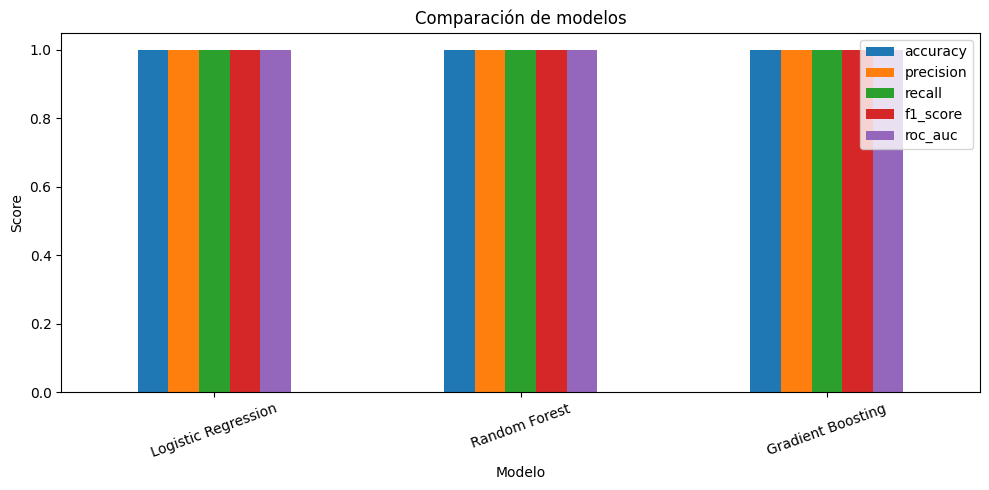

In [22]:
plot_df = results_df.set_index('model')[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']]

ax = plot_df.plot(kind='bar', figsize=(10,5))
ax.set_title('Comparación de modelos')
ax.set_ylabel('Score')
ax.set_xlabel('Modelo')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 9. Matrices de confusión

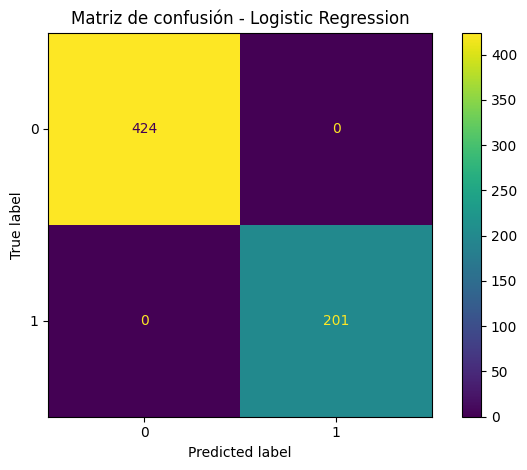

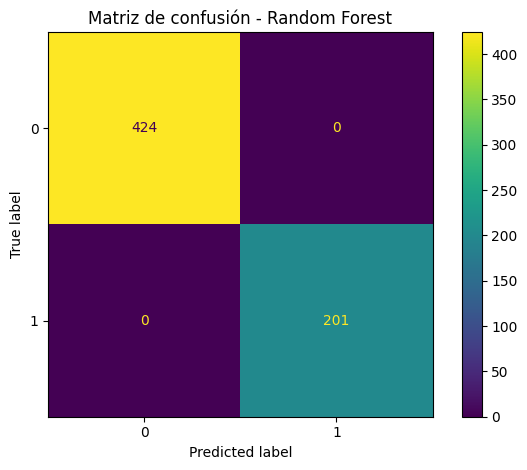

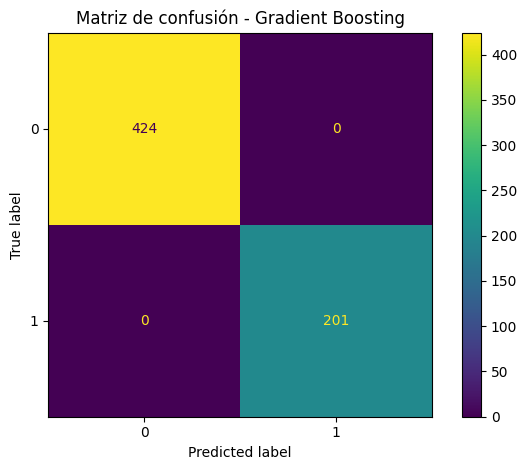

In [23]:
for model_name, pipeline in fitted_pipelines.items():
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Matriz de confusión - {model_name}')
    plt.tight_layout()
    plt.show()


## 10. Curvas ROC

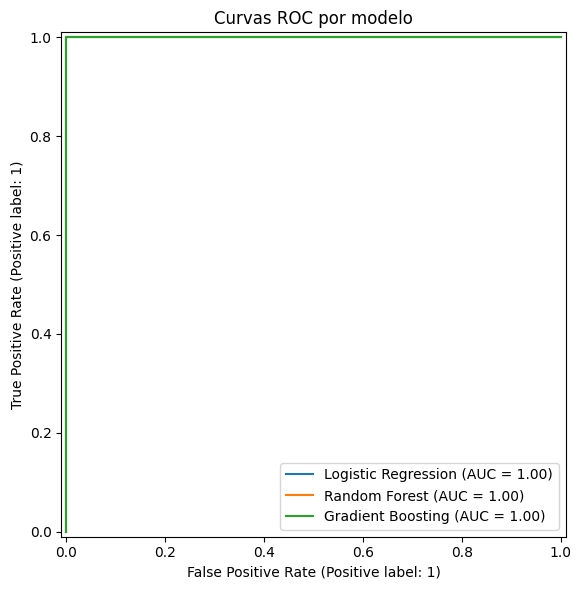

In [24]:
plt.figure(figsize=(8,6))

for model_name, pipeline in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, name=model_name, ax=plt.gca())

plt.title('Curvas ROC por modelo')
plt.tight_layout()
plt.show()


## 11. Classification report del mejor modelo

In [25]:
best_model_name = results_df.iloc[0]['model']
best_pipeline = fitted_pipelines[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
print('Mejor modelo:', best_model_name)
print()
print(classification_report(y_test, y_pred_best, digits=3))


Mejor modelo: Logistic Regression

              precision    recall  f1-score   support

           0      1.000     1.000     1.000       424
           1      1.000     1.000     1.000       201

    accuracy                          1.000       625
   macro avg      1.000     1.000     1.000       625
weighted avg      1.000     1.000     1.000       625



## 12. Importancia de variables

Para modelos basados en árboles, se extraen importancias aproximadas.



Top variables - Random Forest
                              feature  importance
35       cat__renewal_intent_negative    0.436231
36        cat__renewal_intent_neutral    0.219113
37       cat__renewal_intent_positive    0.087596
33   cat__subscription_status_churned    0.079460
32    cat__subscription_status_active    0.059270
9   num__usage_change_vs_prev_quarter    0.016126
20                  num__csat_support    0.015961
18              num__reopened_tickets    0.013137
22             num__sentiment_support    0.007690
8            num__tool_activity_score    0.006540
19           num__avg_resolution_days    0.006354
1                            num__mrr    0.006029
21                 num__sentiment_csm    0.005212
10        num__feature_adoption_score    0.004873
7                num__login_count_30d    0.004170


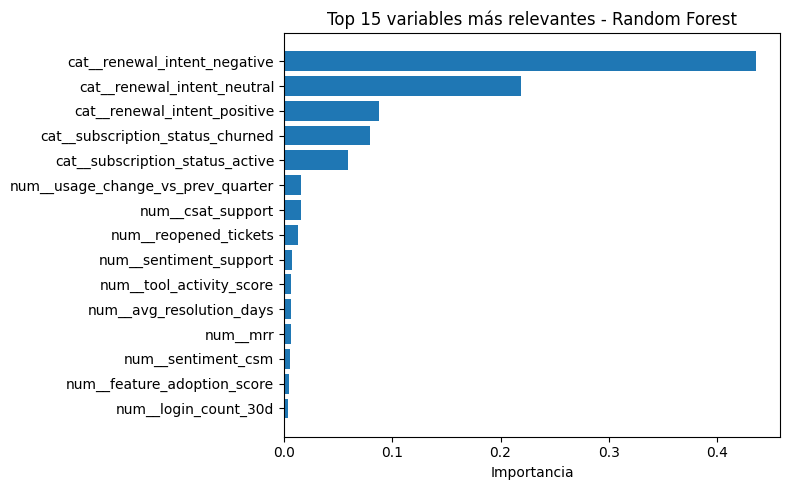


Top variables - Gradient Boosting
                             feature    importance
35      cat__renewal_intent_negative  8.237802e-01
33  cat__subscription_status_churned  1.762198e-01
1                           num__mrr  3.502143e-15
8           num__tool_activity_score  3.472541e-15
16          num__success_plan_active  3.972873e-16
10       num__feature_adoption_score  1.805230e-16
0                 num__tenure_months  9.431554e-17
20                 num__csat_support  2.734666e-17
22            num__sentiment_support  5.776737e-19
31                cat__plan_tier_Pro  0.000000e+00
32   cat__subscription_status_active  0.000000e+00
30               cat__plan_tier_Guru  0.000000e+00
29         cat__plan_tier_Enterprise  0.000000e+00
28           cat__plan_tier_Business  0.000000e+00
27    cat__subscription_type_monthly  0.000000e+00


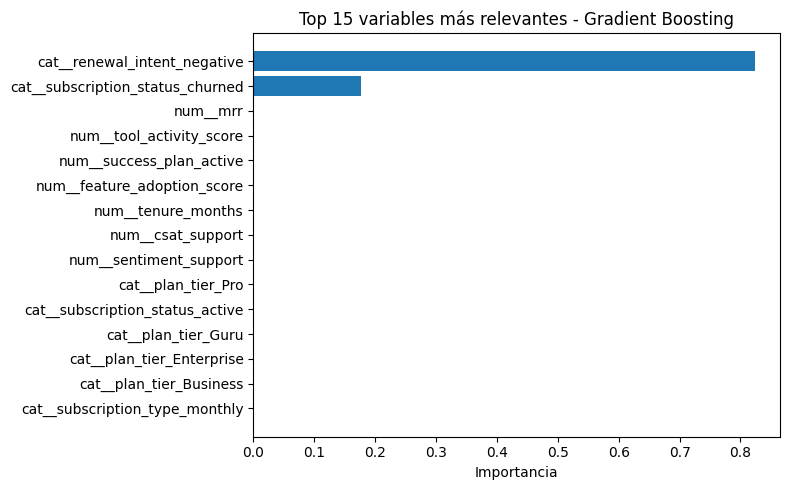

In [26]:
for model_name in ['Random Forest', 'Gradient Boosting']:
    pipeline = fitted_pipelines[model_name]
    model = pipeline.named_steps['model']
    prep = pipeline.named_steps['preprocessor']

    feature_names = prep.get_feature_names_out()
    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False).head(15)

    print(f'\nTop variables - {model_name}')
    print(importance_df)

    plt.figure(figsize=(8,5))
    plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
    plt.title(f'Top 15 variables más relevantes - {model_name}')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.show()


## 13. Guardado del mejor modelo

Se guarda el pipeline completo para usarlo después en el prototipo.


In [27]:
joblib.dump(best_pipeline, 'best_churn_model.pkl')
print('Modelo guardado como best_churn_model.pkl')


Modelo guardado como best_churn_model.pkl


## 14. Tabla resumen para el TFM

In [28]:
summary_for_report = results_df.copy()
metric_cols = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
summary_for_report[metric_cols] = summary_for_report[metric_cols].round(3)
summary_for_report


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0,1.0


## 15. Conclusiones iniciales

Puedes adaptar estas ideas a la memoria:

- La primera aproximación sirve como línea base para validar el problema.
- Los modelos más flexibles mejoran la detección de cuentas con señales de riesgo más complejas.
- El mejor modelo se selecciona no solo por su rendimiento, sino también por su utilidad práctica para el prototipo.
- Las variables relacionadas con engagement, renovación, satisfacción y sentimiento tienden a aparecer entre las más relevantes.
